In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from tqdm import tqdm

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.parity.polynomial import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

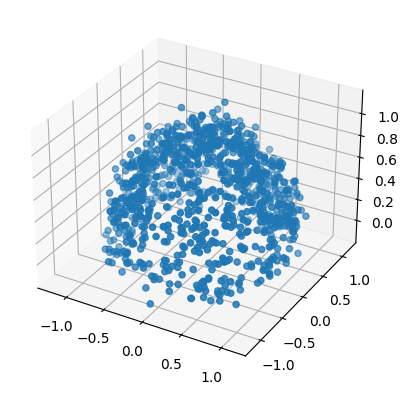

In [ ]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_clean = uniform_sphere_sampling(3, num_samples)
# data_clean_mean = data_clmean
data_train_clean = data_clean
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=nn.Linear(dim, 2 * dim))
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 2
flow = create_flow_model(dim, n_flows, 2)
prior_diffeo = NFlowVectorDiffeomorphism(dim, flow)

n_layers = 2
c_flow = create_conditional_flow_model(dim, n_flows, 2)
posterior_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=0.1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, real_data_reg=None):
    for epoch in range(n_epochs):
        for y in tqdm(train_loader):
            optimizer.zero_grad()
            
            y = y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y)

            if real_data_reg is not None:
                log_p_theta_gt = model.phi.nflow.log_prob(data_clean[0:10].to(device))
                loss -= real_data_reg * log_p_theta_gt.mean()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [8]:
# Train the model
n_epochs = 250
real_data_reg = 1.
train(model, train_loader, optimizer, n_epochs, real_data_reg=real_data_reg)

  0%|          | 0/8 [00:00<?, ?it/s]/home/wdiepeveen/projects/Score-based-Riemannian-geometry-from-corrupted-data/.venv/lib/python3.8/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 8/8 [00:03<00:00,  2.11it/s]


Epoch 1/250, Loss: 63.8378


100%|██████████| 8/8 [00:02<00:00,  3.24it/s]


Epoch 2/250, Loss: 63.2256


100%|██████████| 8/8 [00:01<00:00,  4.55it/s]


...

Epoch 248/250, Loss: 6.8524


100%|██████████| 8/8 [00:01<00:00,  5.85it/s]


Epoch 249/250, Loss: 6.7293


100%|██████████| 8/8 [00:01<00:00,  6.00it/s]

Epoch 250/250, Loss: 6.7166


In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

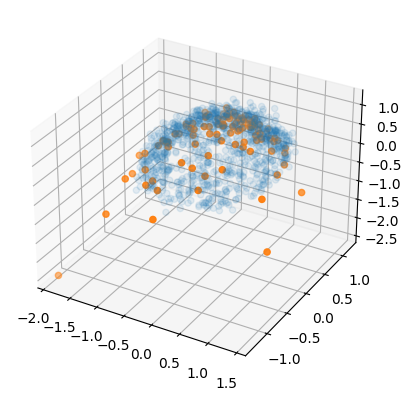

In [11]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

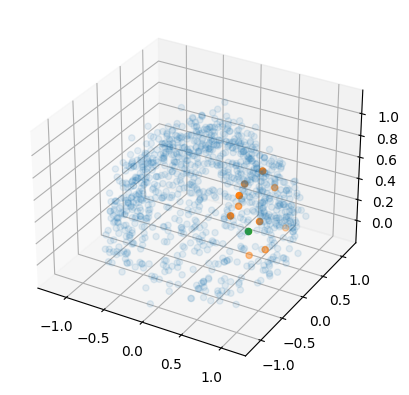

In [12]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.phy.nflow, 10, context.to(device))

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [14]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([1.,0.,0.]).to(device)

In [15]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

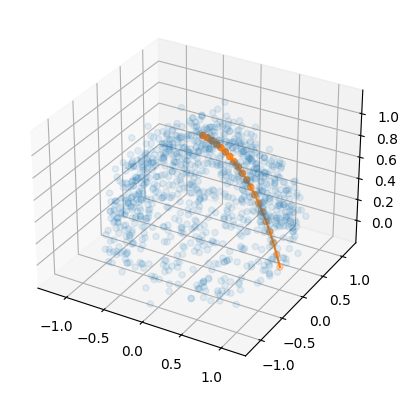

In [16]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

#### RAE construction ####

##### Tangent space PCA #####

In [17]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)

tensor([-0.0038,  0.2379,  0.9479], device='cuda:0', grad_fn=<SelectBackward0>)


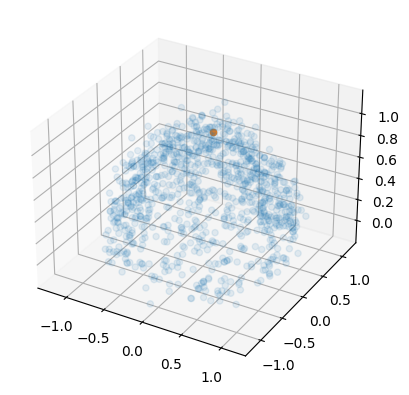

In [18]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [19]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [20]:
# compute low rank approximations
Xi, approximations, _ = l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


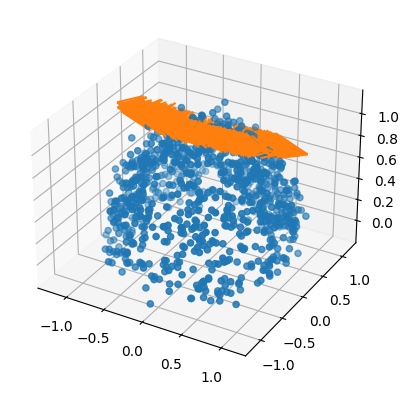

In [21]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             Xi.detach().cpu().numpy()[i, 0], Xi.detach().cpu().numpy()[i, 1], Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


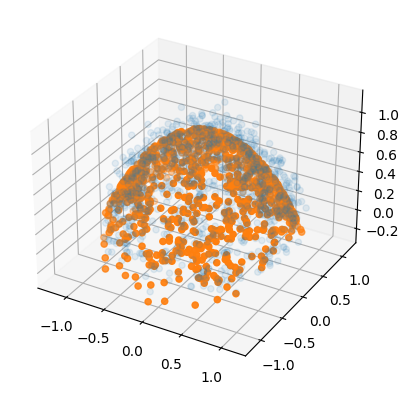

In [22]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [23]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0323, device='cuda:0', grad_fn=<SumBackward0>)


##### Standard Normalizing Flow RAE #####

In [24]:
# Construct RAE
epsilon = 0.1
d_epsilon = 2
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon, device=device)

constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.006268993020057678
constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.006268993020057678


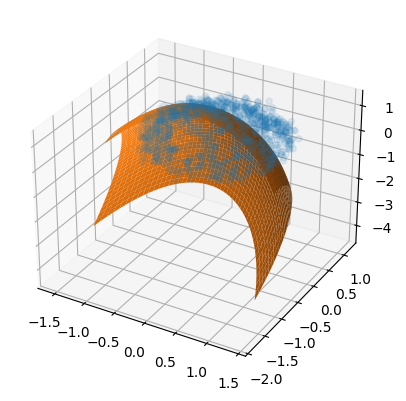

In [25]:
L = 50
x = torch.linspace(-1.5, 1.5, steps=L, device=device)
y = torch.linspace(-1.5, 1.5, steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = rae.decode(coordinates)  
    x_bar = manifold.phi.inverse(torch.zeros(1,3,device=x.device))[0].cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [26]:
rae_approximations = rae.project_on_manifold(data_train.to(device)).detach().cpu().numpy()

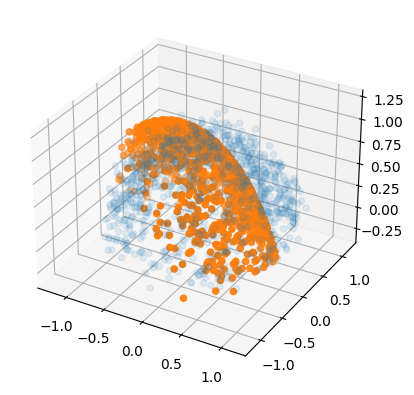

In [27]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rae_approximations[:,0], rae_approximations[:,1], rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [28]:
# compute approximation errors
print(torch.mean((data_train - rae_approximations)**2,0).sum())

tensor(0.1584)


##### Posterior Tangent Space PCA #####

In [29]:
# use all data to sample from the learned conditional (and take the mean per conditioning data point)
# do tangent space pca wrt to the prior diffeomorphism to get the subspace
rec_data_train = torch.zeros(data_train.shape[0], 3)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.phy.nflow, 10, context.to(device))
    rec_data_train[i] = samples.mean(0)

In [30]:
# compute barycentre
rec_bary = manifold.barycentre(rec_data_train.to(device))
print(rec_bary)

tensor([0.0383, 0.1961, 0.8407], device='cuda:0', grad_fn=<SelectBackward0>)


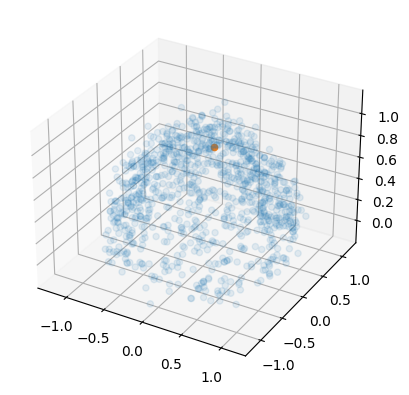

In [31]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [32]:
# construct l2-pga solver
rec_l2_pga_solver = l2TangentSpacePCAVectorSolver(rec_data_train.to(device), manifold, rec_bary)

In [33]:
# compute low rank approximations
rec_Xi, rec_approximations, _ = rec_l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


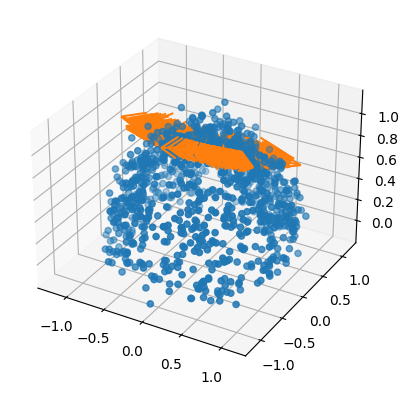

In [34]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(rec_l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], 
             rec_Xi.detach().cpu().numpy()[i, 0], rec_Xi.detach().cpu().numpy()[i, 1], rec_Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


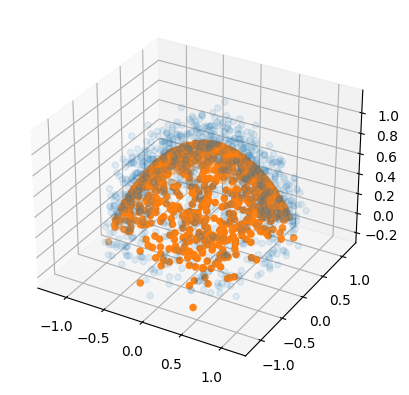

In [35]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_approximations.detach().cpu().numpy()[:,0], rec_approximations.detach().cpu().numpy()[:,1], rec_approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [36]:
print(torch.mean((data_train.to(device) - rec_approximations)**2,0).sum())
print(torch.mean((rec_data_train.to(device) - rec_approximations)**2,0).sum())

tensor(0.0744, device='cuda:0', grad_fn=<SumBackward0>)
tensor(0.0169, device='cuda:0', grad_fn=<SumBackward0>)


##### Posterior RAE #####

In [37]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train.to(device), 2)

constructed a Riemannian autoencoder with latent dimension = 2 and effectice eps = 0.0950031578540802


In [38]:
print(l2_pga_solver.base_point.shape)

torch.Size([3])


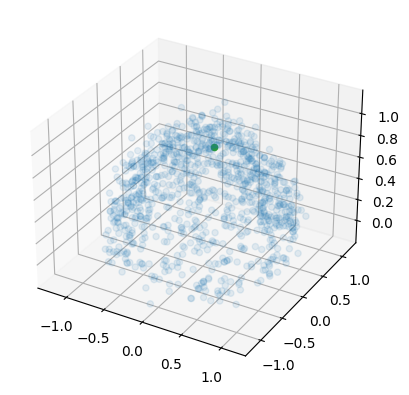

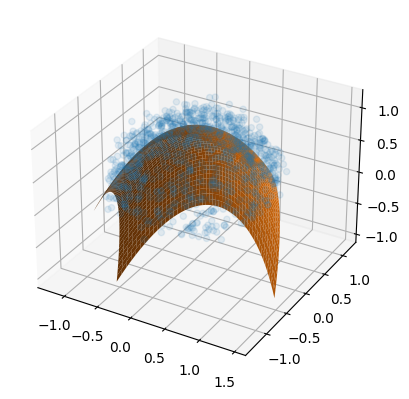

In [39]:
L = 50
x = torch.linspace(-1., 1., steps=L, device=device)
y = torch.linspace(-1., 1., steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = l2_tpca_rae.decode(coordinates)  
    x_bar = l2_tpca_rae.base_point.detach().cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [40]:
rec_l2_tpca_rae_approximations = l2_tpca_rae.project_on_manifold(rec_data_train.to(device)).detach().cpu().numpy()

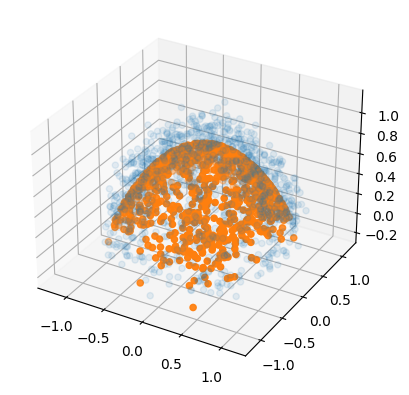

In [41]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_l2_tpca_rae_approximations[:,0], rec_l2_tpca_rae_approximations[:,1], rec_l2_tpca_rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [42]:
# compute approximation errors
print(torch.mean((rec_data_train - rec_l2_tpca_rae_approximations)**2,0).sum())

tensor(0.0169)
